In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

y = df['Survived']
X = df.drop(columns=['Survived'])

X = X.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
X['Embarked'] = X['Embarked'].map({'S': 1, 'C': 2, 'Q': 3})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 결측치를 처리할 때 사용했던 결측치 처리를 다시 나눠서 수행합니다.
X_train['Age'] = X_train['Age'].fillna(X_train['Age'].median())
X_train['Embarked'] = X_train['Embarked'].fillna(X_train['Embarked'].mode()[0])

X_test['Age'] = X_test['Age'].fillna(X_train['Age'].median())
X_test['Embarked'] = X_test['Embarked'].fillna(X_train['Embarked'].mode()[0])

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

model.score(X_test, y_test)

/Users/junhwi/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8044692737430168

이 모델의 진짜 성능을 측정하는 방법은 평가지표를 보는 것입니다.

지금은 정확도로만 측정하고 있지만 이런 분류 학습에 자주 사용되는 평가지표는 아래와 같이 더 있습니다.

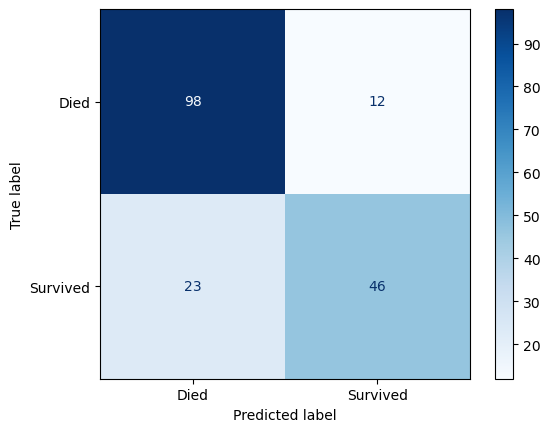

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Died', 'Survived'], cmap='Blues')

이렇게 보면 모델이
- 사망자는 거의 다 맞추고 있지만 (98/110),
- 생존자는 많이 틀리고 있다 (46/69)
는걸 알 수 있다.

이는 타이타닉 데이터에 사망자 수가 생존자 수보다 더 많아 생기는 라벨 불균형의 문제라고 볼 수 있는데, 이런 라벨 불균형을 함께 고려한 정확도를 f1 score를 통해 계산할 수 있다.

In [6]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print(f"F1 score: {f1:.4f}")

F1 score: 0.7244


보면 정확도보다 낮은 수치를 달성한 것을 볼 수 있습니다. 모델이 라벨에 관계없이 균일하게 잘 맞춘다면 정확도와 f1 score는 거의 일치하게 됩니다.

또 다른 지표로는 roccurve가 있습니다.

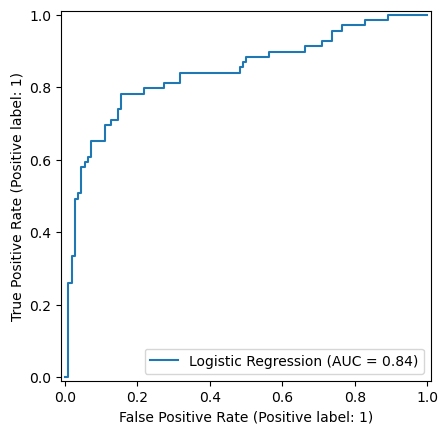

In [7]:
from sklearn.metrics import RocCurveDisplay

y_proba = model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_proba, name='Logistic Regression')

* X축은 False Positive : 실제로 죽은 사람 중에 "생존"이라고 잘못 예측한 비율
* Y축은 True Positive : 실제로 생존한 사람 중에 "생존"이라고 맞게 예측한 비율

그래프는 threshold를 바꿔가며 측정했을 때 모델이 얼마나 잘 예측하냐를 나타냅니다. 기본적으로 그래프가 왼쪽 위에 가까워질수록 좋은 모델이며, 대각선에 가까울수록 그냥 랜덤으로 찍는 것과 같은 성능이라고 보면 됩니다.

AUC는 그래프 아래의 면적을 의미하며, 왼쪽 위에 가까울수록 1에 가까운 수치가 나타납니다.

정확도는 기본적으로 threshold=0.5로 했을 때의 성능을 보여주지만, ROC curve는 모든 threshold에서의 성능을 한번에 보여주기 때문에 이용합니다. (왼쪽 아래 treshold=1, 오른쪽 위 threshold=0)

그 다음 평가지표와 함께 살펴볼 수 있는 것은 모델이 데이터를 어떻게 해석하고 있는지 여부입니다.

Background dataset has 712 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=712 when initializing the masker.


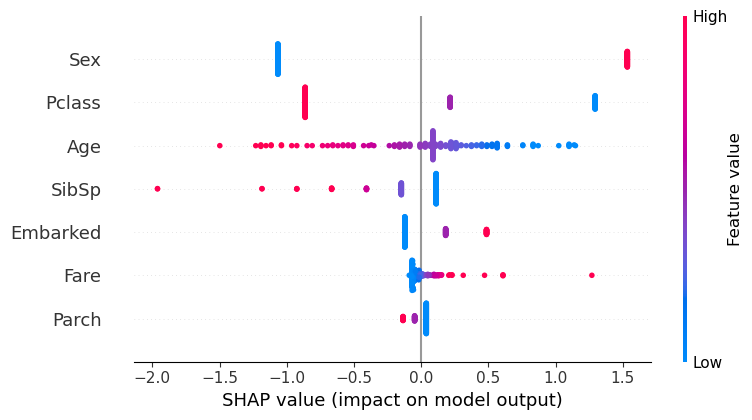

In [4]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

SHAP 그래프입니다. SHAP은 "이 예측에서 각 변수가 얼마나, 어느 방향으로 기여 했는가"를 숫자로 알려주는 값입니다.

이 그래프를 해석하는 방법은,

1. 색상 - 빨간색 = 높은 값 / 파란색 = 낮은 값
2. SHAP value : 해당 데이터가 모델의 예측에 어떤 영향을 미치고 있는지 (양수 = 모델 예측값이 커지도록, 음수 = 모델 예측값이 작아지도록)

ex) Sex 컬럼의 빨간 데이터(여성)가 모델의 예측 값을 높이는데 큰 영향을 미치고 있음. = 여성일 경우 생존율이 올라감.

3. 세로축의 변수 이름 - 위로 갈수록 전체 데이터에서 평균적으로 영향력이 큰 변수
4. 점 하나 = 승객 한 명. 위아래로 길수록 해당 값의 데이터가 많음.

우선 성별이 가장 생존율에 영향을 크게 미치는 것 같으니, 실제 성별과 생존율의 관계를 살펴볼까요?

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


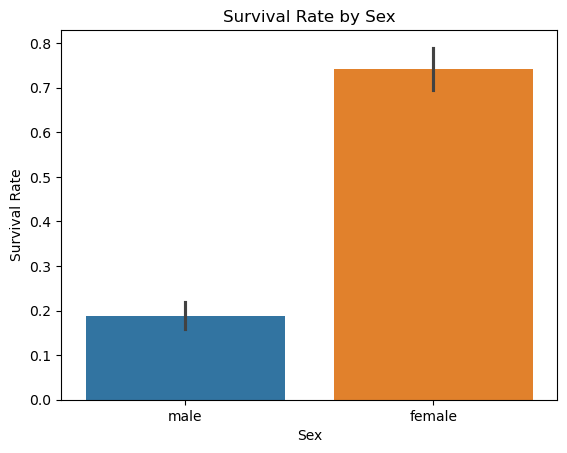

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

survival_rate = df.groupby('Sex')['Survived'].mean()
print(survival_rate)

sns.barplot(x='Sex', y='Survived', data=df, hue='Sex', legend=False)
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Sex')
plt.show()

보면 실제 데이터가 여성의 생존율이 남성보다 압도적으로 높은 것을 볼 수 있습니다. 이런 식으로 각 컬럼과 생존율 사이의 상관관계를 확인하는 것도 가능합니다. 아래 그래프를 보시죠.

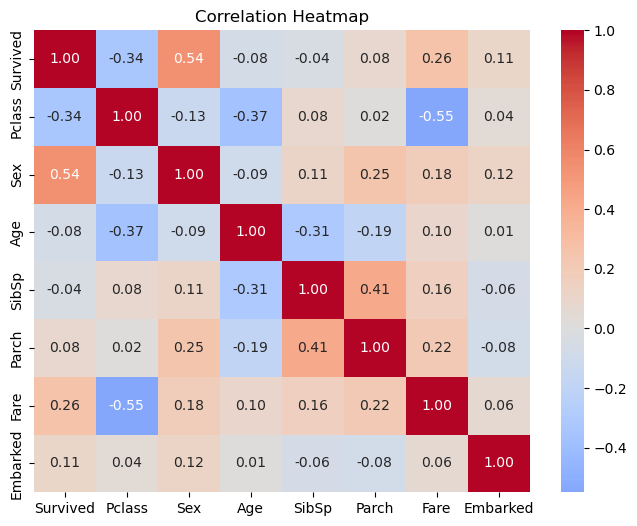

In [9]:
corr_df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin']).copy()
corr_df['Sex'] = corr_df['Sex'].map({'male': 0, 'female': 1})
corr_df['Embarked'] = corr_df['Embarked'].map({'S': 1, 'C': 2, 'Q': 3})

corr = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

Survived 컬럼과 관계 있는 행만 보자면, Sex > Pclass > Fare 순으로 상관관계가 나타나고 있습니다.

지금까지는 train/test를 한 번만 나눠서 성능을 측정했습니다. 그런데 이 test set은 194명(20%)밖에 되지 않아서, 우연히 이 194명에서만 잘/못 나온 결과일 수도 있습니다.

이를 확인하기 위해 **Cross-validation(교차 검증)**을 사용합니다. 데이터를 K개로 나눠서, 매번 다른 부분을 test set으로 사용하며 K번 학습/평가를 반복하고, 그 평균과 편차를 봅니다.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold

X_full = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived']).copy()
X_full['Sex'] = X_full['Sex'].map({'male': 0, 'female': 1})
X_full['Embarked'] = X_full['Embarked'].map({'S': 1, 'C': 2, 'Q': 3})
y_full = df['Survived']

# Age, Embarked 결측치 처리를 Pipeline에 포함시켜서 fold마다 train 데이터로만 학습하도록 합니다.
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = cross_val_score(pipeline, X_full, y_full, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(pipeline, X_full, y_full, cv=cv, scoring='f1')

print(f"Accuracy: {acc_scores.mean():.4f} (+/- {acc_scores.std():.4f})")
print(f"F1 score: {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
print(f"Fold별 Accuracy: {acc_scores}")
print(f"Fold별 F1: {f1_scores}")

Accuracy: 0.7924 (+/- 0.0144)
F1 score: 0.7229 (+/- 0.0228)
Fold별 Accuracy: [0.77653631 0.80337079 0.78651685 0.78089888 0.81460674]
Fold별 F1: [0.71428571 0.72868217 0.69354839 0.71532847 0.76258993]


그러면 이제 모델의 성능을 개선 시키기 위한 여러가지 방법들을 시도해 볼 수 있어야겠죠?

이를 위해 feature engineering을 수행할 수 있습니다. 컬럼에서 새로운 정보를 얻거나, 원래 있던 컬럼끼리 합쳐서 새로운 컬럼을 만들거나 하는 작업이죠.

이런 것들은 보통 아래와 같은 경험들에서 나옵니다.

1. 버려진 컬럼 다시 보기
2. 도메인 지식에서 유추
3. EDA/SHAP 결과에서 힌트 얻기
4. 비슷한 문제를 푼 사례 참고

#### 1. 버려진 컬럼 다시 보기

Name, Ticket, Cabin은 텍스트라서 그대로는 모델에 넣을 수 없어 통째로 버렸었는데, 이 안에 진짜 정보가 없는지 하나씩 다시 살펴보겠습니다.

In [12]:
df['Name'].head()

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

- **Name** → 이름 안에 "Mr.", "Mrs.", "Miss." 같은 호칭(Title)이 있습니다. 이건 단순 Sex보다 더 세밀하게 사람을 구분해줄 수 있습니다 (예: 결혼 여부, 아동 여부, 귀족 여부 등).
- **Cabin** → 결측치가 많아서 버렸지만, "Cabin 정보가 있다/없다" 자체가 신호일 수 있습니다 (Cabin이 기록된 사람은 대체로 요금이 비싼 상위 객실일 가능성이 있습니다).
- **Ticket** → 티켓 번호 자체는 규칙성이 약해서 이번엔 넘어가겠습니다.

먼저 Name에서 Title을 뽑아보겠습니다.

In [11]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
print(df['Title'].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64


Mr, Miss, Mrs, Master가 대부분이고 나머지는 각각 1~7명뿐인 희귀한 호칭들입니다. 이렇게 개수가 너무 적은 카테고리는 모델이 제대로 학습하기 어렵고 overfitting 위험도 있으니, 하나로 묶어 "Rare"로 처리하겠습니다.

Title
Mrs       0.792000
Miss      0.697802
Master    0.575000
Rare      0.444444
Mr        0.156673
Name: Survived, dtype: float64


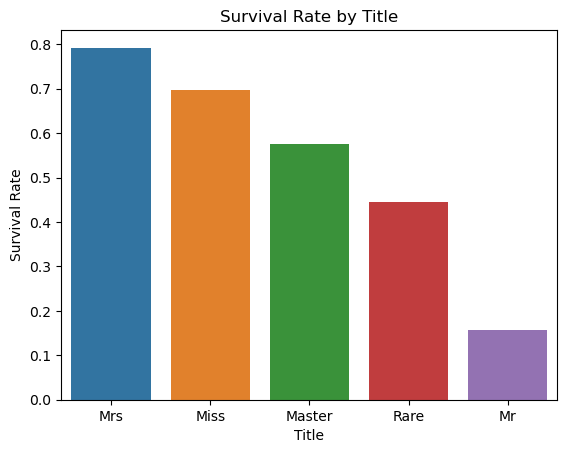

In [13]:
main_titles = ['Mr', 'Miss', 'Mrs', 'Master']
df['Title'] = df['Title'].apply(lambda t: t if t in main_titles else 'Rare')

survival_by_title = df.groupby('Title')['Survived'].mean().sort_values(ascending=False)
print(survival_by_title)

sns.barplot(x=survival_by_title.index, y=survival_by_title.values, hue=survival_by_title.index, legend=False)
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Title')
plt.show()

Title별 생존율이 Mrs(0.79) > Miss(0.70) > Master(0.575) > Rare(0.44) > Mr(0.16) 순으로 뚜렷하게 갈립니다.

특히 주목할 점은 **Master(어린 남자아이)의 생존율(0.575)이 전체 남성 평균(약 0.19)보다 훨씬 높다**는 것입니다. 즉 Title은 단순히 Sex를 다시 나타내는 게 아니라, "성별 + 나이대(아동 여부) + 결혼 여부"를 동시에 담고 있어서 Sex 하나만 볼 때보다 더 세밀한 신호를 줄 수 있습니다. 이 변수를 모델에 추가할 후보로 유력해 보입니다.

다음으로 Cabin을 살펴보겠습니다.

HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64


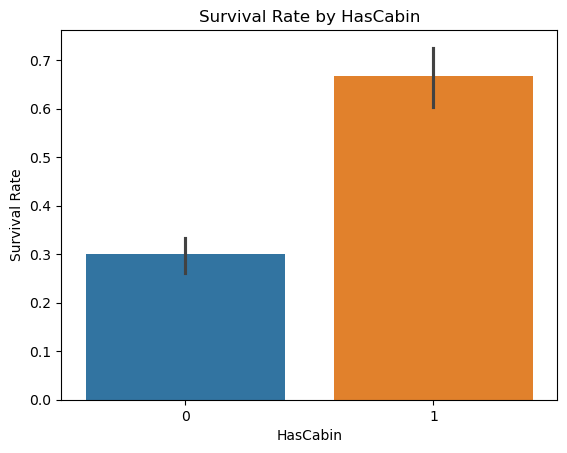

In [14]:
df['HasCabin'] = df['Cabin'].notna().astype(int)

survival_by_cabin = df.groupby('HasCabin')['Survived'].mean()
print(survival_by_cabin)

sns.barplot(x='HasCabin', y='Survived', data=df, hue='HasCabin', legend=False)
plt.ylabel('Survival Rate')
plt.title('Survival Rate by HasCabin')
plt.show()

Cabin 기록이 있는 사람(204명)의 생존율은 0.667, 없는 사람(687명)은 0.300으로 차이가 큽니다. 다만 이건 온전히 "Cabin이 있어서 생존한 것"이 아니라, Cabin이 기록되는 사람은 대체로 Pclass가 높은(비싼 표를 산) 승객일 가능성이 커서 생기는 간접적인 효과일 수 있습니다. 그래도 모델 입장에서는 예측에 도움이 되는 신호이니 feature로 추가할 만합니다.

정리하면, 버려졌던 컬럼에서 두 가지 새 feature 후보를 찾았습니다.
- **Title** (Name에서 추출): Mr / Miss / Mrs / Master / Rare
- **HasCabin** (Cabin 존재 여부): 0 / 1

이제 이 두 feature를 모델에 추가했을 때 baseline(Accuracy 0.792, F1 0.723)보다 실제로 좋아지는지 cross-validation으로 검증해보겠습니다.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X_fe = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived']).copy()
X_fe['Sex'] = X_fe['Sex'].map({'male': 0, 'female': 1})
X_fe['Embarked'] = X_fe['Embarked'].map({'S': 1, 'C': 2, 'Q': 3})
y_fe = df['Survived']

numeric_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'HasCabin']
categorical_cols = ['Title']

# Title은 문자열 카테고리이므로 OneHotEncoder로 처리합니다.
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

pipeline_fe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

acc_scores_fe = cross_val_score(pipeline_fe, X_fe, y_fe, cv=cv, scoring='accuracy')
f1_scores_fe = cross_val_score(pipeline_fe, X_fe, y_fe, cv=cv, scoring='f1')

print(f"[Baseline]        Accuracy: {acc_scores.mean():.4f}, F1: {f1_scores.mean():.4f}")
print(f"[Title+HasCabin]  Accuracy: {acc_scores_fe.mean():.4f}, F1: {f1_scores_fe.mean():.4f}")

[Baseline]        Accuracy: 0.7924, F1: 0.7229
[Title+HasCabin]  Accuracy: 0.8215, F1: 0.7631


**결과: Accuracy 0.792 → 0.822, F1 0.723 → 0.763**

두 feature를 추가한 것만으로 baseline보다 뚜렷하게 개선됐습니다. 특히 F1 score가 크게 오른 것은, 처음 confusion matrix에서 봤던 "생존자를 놓치는 문제"가 어느 정도 완화됐다는 뜻입니다.

이렇게 "버려진 컬럼 다시 보기"만으로도 의미 있는 개선을 얻었습니다. 다음으로는 도메인 지식(가족 수 등)이나 SHAP에서 얻은 힌트(Age 구간화 등)로 넘어가볼 수 있습니다.

개선된 모델(Title + HasCabin 포함)이 실제로 어떤 변수를 어떻게 활용하는지 SHAP으로 다시 확인해보겠습니다.

이번엔 Title이 OneHotEncoder로 여러 컬럼(Title_Mr, Title_Mrs, ...)으로 나뉘기 때문에, 모델 내부에서 실제로 사용하는 전처리된 컬럼 기준으로 SHAP을 계산합니다.

Background dataset has 712 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=712 when initializing the masker.


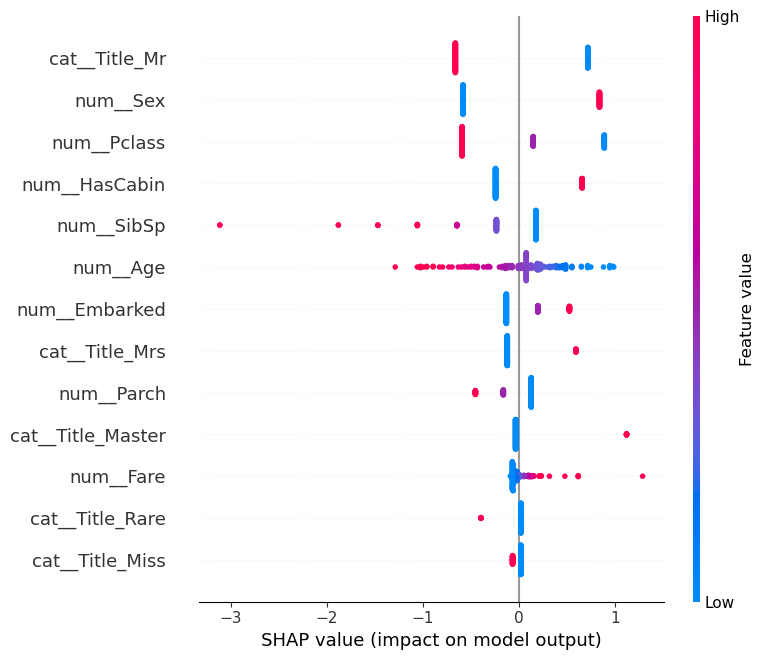

In [16]:
import scipy.sparse as sp

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.2, stratify=y_fe, random_state=42)
pipeline_fe.fit(X_train_fe, y_train_fe)

preprocessor_fitted = pipeline_fe.named_steps['preprocessor']
model_fe = pipeline_fe.named_steps['model']

X_train_transformed = preprocessor_fitted.transform(X_train_fe)
X_test_transformed = preprocessor_fitted.transform(X_test_fe)

if sp.issparse(X_train_transformed):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed = X_test_transformed.toarray()

feature_names = preprocessor_fitted.get_feature_names_out()

explainer_fe = shap.Explainer(model_fe, X_train_transformed, feature_names=feature_names)
shap_values_fe = explainer_fe(X_test_transformed)

shap.summary_plot(shap_values_fe, X_test_transformed, feature_names=feature_names)

보면 Mr 호칭이 생존율에 영향을 많이 미치는 것을 볼 수 있습니다. Mr. 호칭이 달려있다면 사망으로 예측되는 경향이 강하다는 것이죠.

또 HasCabin을 보면 앞서 관측했던대로 Cabin이 기록된 사람의 생존 예측 경향이 강해지는 것이 확인되었습니다.

#### 2. 도메인 지식에서 유추

배를 탈출하는 상황을 상식적으로 생각해보면:
- **혼자 탄 사람**은 챙길 사람이 없어서 더 빠르게 움직였을 수 있고
- **대가족과 함께 탄 사람**은 다 같이 모이느라 대피가 늦어지거나, 구명보트 자리가 부족했을 수 있습니다

즉 SibSp(형제/배우자 수)와 Parch(부모/자녀 수)를 각각 보는 것보다, 둘을 합친 **"가족 규모(FamilySize)"** 자체가 더 의미 있는 신호일 수 있습니다. 그리고 그 중에서도 **"혼자인가(IsAlone)"** 여부가 특히 중요한 경계일 수 있습니다.

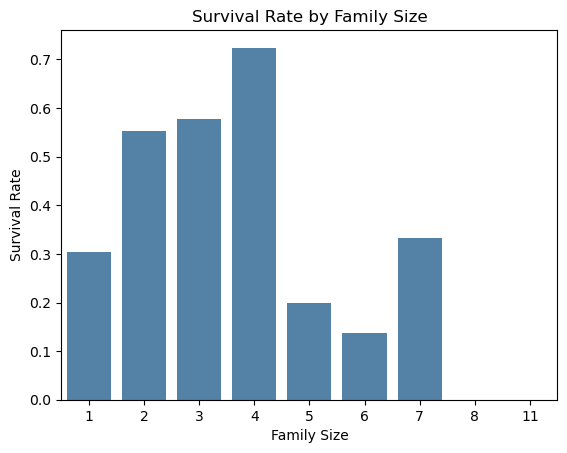

In [21]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

survival_by_family = df.groupby('FamilySize')['Survived'].mean()

sns.barplot(x=survival_by_family.index, y=survival_by_family.values, color='steelblue')
plt.ylabel('Survival Rate')
plt.xlabel('Family Size')
plt.title('Survival Rate by Family Size')
plt.show()

예상과 살짝 다른 패턴이 나왔습니다. 생존율이 단순히 "혼자일수록 좋다/가족이 많을수록 나쁘다"는 일직선이 아니라:

- 혼자(1명): 0.30
- 2~4명: 0.55~0.72로 **오히려 가장 높음**
- 5명 이상: 0.00~0.33으로 다시 급락

즉 **"적당한 크기의 가족과 함께"가 가장 유리하고, 혼자이거나 대가족이면 불리한 역U자형 패턴**입니다. 서로 도와줄 사람이 1~3명 있는 게 도움이 되지만, 대가족은 다 함께 움직이다 오히려 대피가 늦어졌을 것이라는 추측과 맞아떨어집니다.

이 비선형적인 패턴은 Logistic Regression처럼 선형 모델에게는 어려운 관계입니다 (SibSp, Parch를 그냥 숫자로 넣으면 "많을수록 계속 나빠진다"는 선형 관계만 학습할 수 있어요). 발견한 패턴 자체가 "정점이 2~4명에 있다"는 것이므로, 이를 그대로 담은 **IsMidFamily(가족 규모 2~4명 여부)**를 feature로 만들겠습니다.

In [22]:
df['IsMidFamily'] = df['FamilySize'].between(2, 4).astype(int)

X_fe2 = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived']).copy()
X_fe2['Sex'] = X_fe2['Sex'].map({'male': 0, 'female': 1})
X_fe2['Embarked'] = X_fe2['Embarked'].map({'S': 1, 'C': 2, 'Q': 3})
y_fe2 = df['Survived']

numeric_cols2 = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'HasCabin', 'IsMidFamily']
categorical_cols2 = ['Title']

preprocessor2 = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols2),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols2)
])

pipeline_fe2 = Pipeline([
    ('preprocessor', preprocessor2),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

acc_scores_fe2 = cross_val_score(pipeline_fe2, X_fe2, y_fe2, cv=cv, scoring='accuracy')
f1_scores_fe2 = cross_val_score(pipeline_fe2, X_fe2, y_fe2, cv=cv, scoring='f1')

print(f"[Baseline]         Accuracy: {acc_scores.mean():.4f}, F1: {f1_scores.mean():.4f}")
print(f"[Title+HasCabin]   Accuracy: {acc_scores_fe.mean():.4f}, F1: {f1_scores_fe.mean():.4f}")
print(f"[+ IsMidFamily]    Accuracy: {acc_scores_fe2.mean():.4f}, F1: {f1_scores_fe2.mean():.4f}")

[Baseline]         Accuracy: 0.7924, F1: 0.7229
[Title+HasCabin]   Accuracy: 0.8215, F1: 0.7631
[+ IsMidFamily]    Accuracy: 0.8316, F1: 0.7746


**결과: Accuracy 0.822 → 0.832, F1 0.763 → 0.775**

IsMidFamily를 추가한 것만으로 baseline 대비 뚜렷한 개선이 이어졌습니다. EDA에서 발견한 "가족 규모 2~4명이 정점"이라는 실제 패턴을 그대로 변수로 옮긴 게 효과적이었습니다.

이번 모델(Title + HasCabin + IsMidFamily 포함)의 SHAP 그래프도 확인해보겠습니다.

Background dataset has 712 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=712 when initializing the masker.


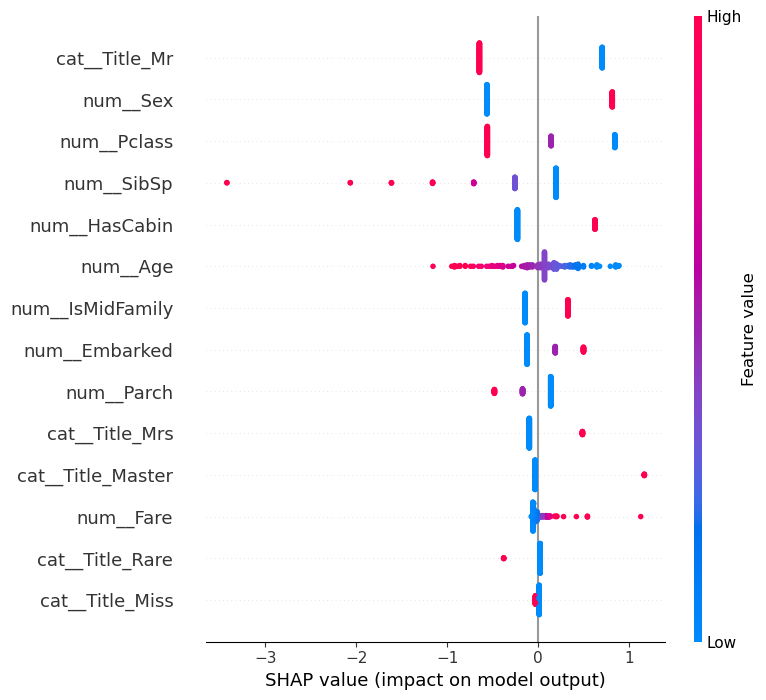

In [24]:
X_train_fe2, X_test_fe2, y_train_fe2, y_test_fe2 = train_test_split(X_fe2, y_fe2, test_size=0.2, stratify=y_fe2, random_state=42)
pipeline_fe2.fit(X_train_fe2, y_train_fe2)

preprocessor_fitted2 = pipeline_fe2.named_steps['preprocessor']
model_fe2 = pipeline_fe2.named_steps['model']

X_train_transformed2 = preprocessor_fitted2.transform(X_train_fe2)
X_test_transformed2 = preprocessor_fitted2.transform(X_test_fe2)

if sp.issparse(X_train_transformed2):
    X_train_transformed2 = X_train_transformed2.toarray()
    X_test_transformed2 = X_test_transformed2.toarray()

feature_names2 = preprocessor_fitted2.get_feature_names_out()

explainer_fe2 = shap.Explainer(model_fe2, X_train_transformed2, feature_names=feature_names2)
shap_values_fe2 = explainer_fe2(X_test_transformed2)

shap.summary_plot(shap_values_fe2, X_test_transformed2, feature_names=feature_names2)

num__IsMidFamily를 보면 빨간 점(가족 2~4명)이 +0.2~+0.4 쪽에, 파란 점(그 외)이 -0.1~-0.2 쪽에 있어서 예상했던 방향("적당한 가족 규모면 생존에 유리")이 그대로 확인됩니다.

#### 3. EDA/SHAP 결과에서 힌트 얻기

앞서 SHAP 그래프에서 num__Age 행을 보면, 다른 변수들과 달리 빨강/파랑이 뚜렷하게 갈리지 않고 0 근처에 촘촘하게 뭉쳐 있었습니다. 이건 Age가 "값이 클수록/작을수록 계속 좋아진다"는 선형적인 관계가 아니라, 특정 구간에서만 다른 패턴을 보이는 비선형적인 변수일 가능성을 시사합니다.

실제로 나이를 구간별로 나눠서 생존율을 확인해보겠습니다.

                   mean  count
AgeBin                        
Child(0-12)    0.579710     69
Teen(12-18)    0.428571     70
Adult(18-35)   0.382682    358
MidAge(35-60)  0.400000    195
Senior(60+)    0.227273     22


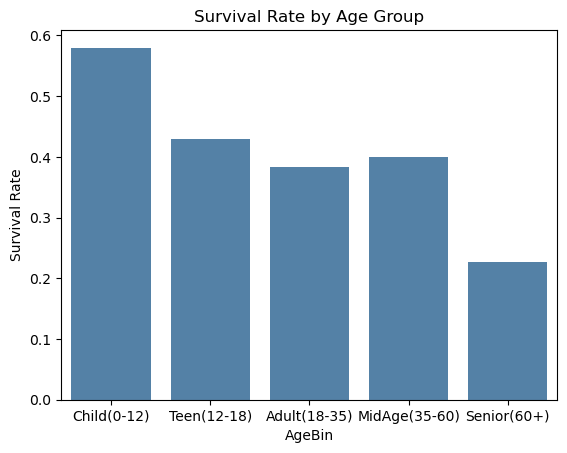

In [25]:
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100],
                       labels=['Child(0-12)', 'Teen(12-18)', 'Adult(18-35)', 'MidAge(35-60)', 'Senior(60+)'])

survival_by_age = df.groupby('AgeBin', observed=True)['Survived'].agg(['mean', 'count'])
print(survival_by_age)

sns.barplot(x=survival_by_age.index, y=survival_by_age['mean'], color='steelblue')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Age Group')
plt.show()

Child(0-12)만 생존율 0.58로 확연히 높고, 나머지 구간(Teen~Senior)은 0.23~0.43 사이에서 큰 차이 없이 뒤섞여 있습니다. 즉 "나이가 어릴수록 계속 유리해진다"는 매끈한 관계가 아니라, **"12세 이하냐 아니냐"라는 하나의 경계선**이 대부분의 신호를 담고 있는 것으로 보입니다.

(참고로 이 신호는 이미 Title의 "Master" 카테고리와 상당 부분 겹칠 수 있습니다 — Master는 대체로 어린 남자아이를 가리키는 호칭이었으니까요. 다만 Master는 남자아이만 포함하고 여자아이는 포함하지 않으므로, 성별과 무관하게 "아동인가"를 표현하는 IsChild 변수는 여전히 추가할 가치가 있는지 검증해볼 만합니다.)

In [26]:
df['IsChild'] = (df['Age'] < 12).astype(int)

X_fe3 = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived', 'AgeBin']).copy()
X_fe3['Sex'] = X_fe3['Sex'].map({'male': 0, 'female': 1})
X_fe3['Embarked'] = X_fe3['Embarked'].map({'S': 1, 'C': 2, 'Q': 3})
y_fe3 = df['Survived']

numeric_cols3 = numeric_cols2 + ['IsChild']

preprocessor3 = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols3),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols2)
])

pipeline_fe3 = Pipeline([
    ('preprocessor', preprocessor3),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

acc_scores_fe3 = cross_val_score(pipeline_fe3, X_fe3, y_fe3, cv=cv, scoring='accuracy')
f1_scores_fe3 = cross_val_score(pipeline_fe3, X_fe3, y_fe3, cv=cv, scoring='f1')

print(f"[+ IsMidFamily]           Accuracy: {acc_scores_fe2.mean():.4f}, F1: {f1_scores_fe2.mean():.4f}")
print(f"[+ IsMidFamily + IsChild] Accuracy: {acc_scores_fe3.mean():.4f}, F1: {f1_scores_fe3.mean():.4f}")

[+ IsMidFamily]           Accuracy: 0.8316, F1: 0.7746
[+ IsMidFamily + IsChild] Accuracy: 0.8316, F1: 0.7746


**결과: 성능이 전혀 변하지 않았습니다 (0.8316 / 0.7746, 소수점까지 동일).**

실제로 IsChild 추가 전후로 예측이 바뀐 사람이 정확히 0명이었습니다. 계수 자체는 0이 아니지만(로지스틱 회귀 계수 확인 결과 약 +0.22), 이미 Title_Master(어린 남자아이 호칭), Age, Sex, Pclass의 조합만으로 "이 사람이 아동인지"에 대한 정보를 충분히 담고 있어서, IsChild가 추가로 뒤집을 수 있는 경계 케이스가 하나도 없었던 것입니다.

이건 처음 EDA에서 봤던 "12세 이하 생존율이 확연히 높다"는 관찰이 틀린 게 아니라, **그 신호가 이미 다른 변수들(특히 Title)을 통해 모델에 들어가 있었다**는 뜻입니다. 이렇게 "그럴듯해 보이는 가설도 실제로는 이미 커버되고 있어서 추가 효과가 없을 수 있다"는 것 역시 검증을 통해서만 알 수 있는 중요한 교훈입니다.

### 마무리: 왜 "해석 가능한 AI"가 중요한가

이번 실습에서 우리는 단순히 정확도 숫자를 올리는 데 그치지 않고, 매 단계마다 "이 모델이 왜 이렇게 예측하는가"를 SHAP으로 들여다봤습니다. 그리고 그 덕분에 몇 가지 중요한 순간들이 있었습니다.

- Confusion matrix로 "생존자를 놓치고 있다"는 약점을 발견했고
- SHAP으로 "Sex, Pclass가 지배적이고 Age는 애매하다"는 걸 확인했고
- 그 힌트를 따라 Title, HasCabin, IsMidFamily 같은 feature를 만들어 실제로 성능을 개선했고
- 심지어 "그럴듯해 보였던 IsAlone, IsChild가 사실은 최선이 아니거나 이미 다른 변수에 흡수돼 있었다"는 것도 검증을 통해 걸러낼 수 있었습니다.

만약 모델을 블랙박스로만 다뤘다면, 정확도가 오르고 내리는 이유를 전혀 알지 못한 채 "이 feature를 넣었더니 됐다/안 됐다"만 반복했을 거예요. 해석 가능성은 단지 "설명을 위한 그림"이 아니라, **다음에 뭘 시도해야 할지 알려주는 나침반이자, 내가 세운 가설이 틀렸을 때 이를 잡아내는 검증 도구**였습니다.

좋은 모델을 만드는 것과, 그 모델을 이해하는 것은 별개의 능력이고, 후자가 있어야 전자도 더 잘할 수 있다 — 이게 이번 실습에서 얻은 가장 큰 교훈이라고 생각합니다.